In [1]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
     ('order_items.csv', 'order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='password',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'D:/Jupyter notebook/Sales'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

In [3]:
db=mysql.connector.connect(host = "localhost",
                       username = "root",
                       password = "password",
                       database= "ecommerce")

cur = db.cursor()                       
                       

 # List all unique cities where customers are located.  



In [4]:
query = """select distinct customer_city from customers"""

cur.execute(query)
data = cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# 2. Count the number of orders placed in 2017.

In [5]:
query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)
data = cur.fetchall()
data[0][0]

225505

# 3. Find the total sales per category.

In [6]:
query = """select upper (products.product_category) as category, 
round(sum(payments.payment_value),2) as sales 	
from products 
inner join order_items on products.product_id = order_items.product_id
inner join payments on order_items.order_id =  payments.order_id 
group by category; """

cur.execute(query)
data = cur.fetchall()
data

[('PERFUMERY', 10134773.2),
 ('FURNITURE DECORATION', 28603527.84),
 ('TELEPHONY', 9737641.01),
 ('BED TABLE BATH', 34251073.42),
 ('AUTOMOTIVE', 17045886.62),
 ('COMPUTER ACCESSORIES', 31706608.93),
 ('HOUSEWARES', 21895162.61),
 ('BABIES', 10796913.19),
 ('TOYS', 12380753.79),
 ('FURNITURE OFFICE', 12936529.74),
 ('COOL STUFF', 15593960.0),
 ('HEALTH BEAUTY', 33147462.39),
 ('PET SHOP', 6225379.41),
 ('GENERAL INTEREST BOOKS', 1293895.19),
 ('STATIONARY STORE', 6348801.39),
 ('WATCHES PRESENT', 28584333.57),
 ('PCS', 5582430.99),
 ('CLIMATIZATION', 1823413.19),
 ('CONSTRUCTION TOOLS CONSTRUCTION', 4829512.61),
 ('SPORT LEISURE', 27842551.18),
 ('BAGS ACCESSORIES', 3743025.81),
 ('ELECTRONICS', 5197141.99),
 ('CASA CONSTRUCAO', 2732905.81),
 ('GAMES CONSOLES', 3909607.58),
 ('FASHION BAGS AND ACCESSORIES', 4363165.6),
 ('HOME APPLIANCES', 1910645.4),
 ('GARDEN TOOLS', 16765615.02),
 ('AGRO INDUSTRIA E COMERCIO', 2374612.21),
 (None, 5056034.2),
 ('AUDIO', 1206492.4),
 ('TECHNICAL BOOK

# 4. Calculate the percentage of orders that were paid in installments.

In [7]:
query = """select (
 sum(case 
 when payment_installments >= 1 then 1
 else 0 end) /count(*)*100) as percentage_installments
 from payments;"""
cur.execute(query)
data = cur.fetchall()
data[0][0]

Decimal('99.9981')

# 5. Count the number of customers from each state. 


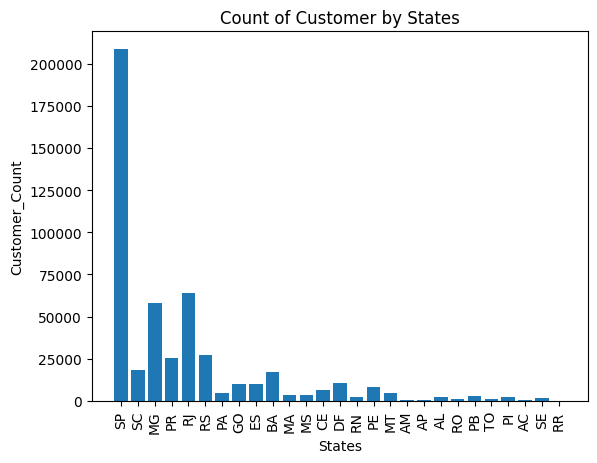

In [8]:
query = """select count(customer_id), customer_state	
from customers
group by customer_state """
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame (data, columns=['customer_count', 'state'])

plt.bar(df['state'], df['customer_count'])
plt.xticks(rotation= 90)
plt.xlabel("States")
plt.ylabel("Customer_Count")
plt.title("Count of Customer by States")
plt.show()


# 6. Calculate the number of orders per month in 2018. 

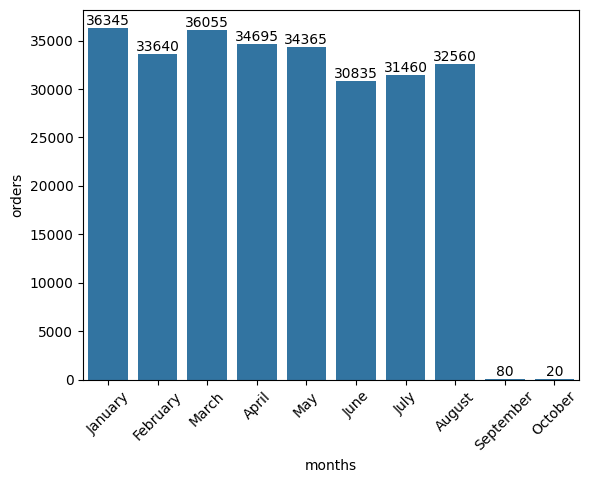

In [29]:
query = """ select monthname(order_purchase_timestamp) as months , count(order_id) as orders
from orders
where year(order_purchase_timestamp) = 2018 group by months """
cur.execute(query)
data = cur.fetchall()
data

df= pd.DataFrame(data, columns= ['months', 'orders'])
o= ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]
ax= sns.barplot(x = 'months', y = 'orders', data= df, order=o, ) 
# order is the biultin keyword argument
plt.xticks(rotation =45)
ax.bar_label(ax.containers[0])
plt.show()

# 7. Find the average number of products per order, grouped by customer city. 

In [10]:
query = """ with count_per_order as (select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders
join order_items on order_items.order_id = orders.order_id
group by  orders.order_id, orders.customer_id)

select customers.customer_city , round(avg(count_per_order.oc),2) as average_orders
from customers 
join count_per_order on count_per_order.customer_id = customers.customer_id
group by customer_city
order by average_orders desc"""
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data, columns = ["customer_city", "avaerage product/order"])
df.head()

,customer_city,avaerage product/order
0,padre carvalho,70.00
1,celso ramos,65.00
2,datas,60.00
3,candido godoi,60.00
4,matias olimpio,50.00


# 8. Calculate the percentage of total revenue contributed by each product category.

In [11]:
query = """ with a as (select upper (products.product_category) as category, 
round(sum(payments.payment_value),2) as sales 	
from products 
inner join order_items on products.product_id = order_items.product_id
inner join payments on order_items.order_id =  payments.order_id 
group by category
order by sales desc)

select category , round((sales/(select sum(payment_value)from payments))*100, 2) as percentage_of_sale
from a"""
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data, columns = ["Category", "percentage of sale"])
df.head()


,Category,percentage of sale
0,BED TABLE BATH,106.98
1,HEALTH BEAUTY,103.53
2,COMPUTER ACCESSORIES,99.03
3,FURNITURE DECORATION,89.34
4,WATCHES PRESENT,89.28


# 9. Identify the correlation between product price and the number of times a product has been purchased.

In [12]:
query = """ select products.product_category, count(order_items.product_id), round (avg(order_items.price), 2)
from products 
join order_items on order_items.product_id = products.product_id
group by product_category"""
cur.execute(query)
data = cur.fetchall()
data

df=pd.DataFrame(data, columns = ["Category", "order_count", "avg_price"])
df.head()

cor= df[["order_count","avg_price"]].corr()
cor

,order_count,avg_price
order_count,1.000000,-0.106315
avg_price,-0.106315,1.000000


# 10. Calculate the total revenue generated by each seller, and rank them by revenue. 

<Axes: xlabel='sellers', ylabel='revenue'>

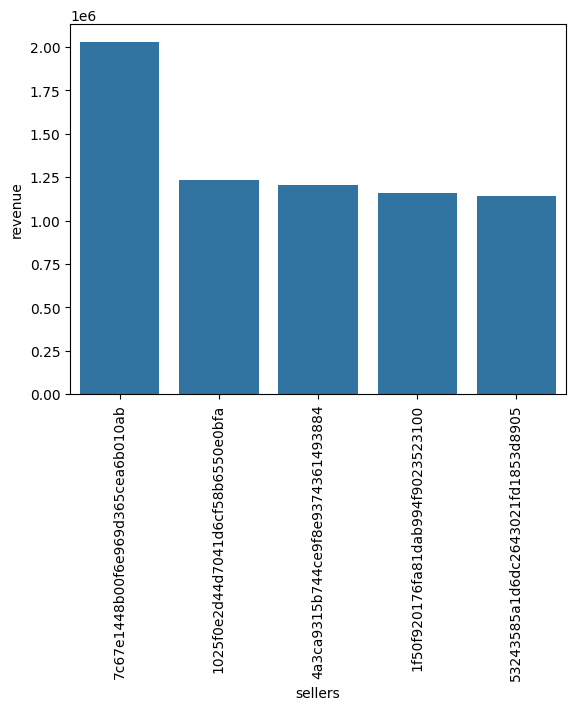

In [13]:
query = """ select *, dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value)as revenue
from order_items
join  payments on order_items.order_id = payments.order_id
group by seller_id) as a"""

cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data, columns = ["sellers", "revenue", "rank"])
df=df.head()
plt.xticks(rotation =90)
sns.barplot(x= "sellers", y = "revenue", data=df )

# 11. Calculate the moving average of order values for each customer over their order history. 

In [14]:
query = """ select customer_id, order_purchase_timestamp, payment, avg(payment) over (partition by customer_id order by order_purchase_timestamp 
rows between 2 preceding and current row ) as mov_avg 
from
(select orders.customer_id, orders.order_purchase_timestamp  , payments.payment_value as payment
from orders	
join payments on orders.order_id  = payments.order_id)as a;"""

cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data, columns = ["customer_id", "order_purchase_timestamp", "payment","avg(payment)"])
df.head()

,customer_id,order_purchase_timestamp,payment,avg(payment)
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998


# 12. Calculate the cumulative sales per month for each year. 

In [19]:
query = """ select year, month, total_payments, sum(total_payments) over (order by year, month)  as cumulative_sum
from 
(select year(orders.order_purchase_timestamp) as year ,
 month(orders.order_purchase_timestamp) as month, round(sum(payments.payment_value),2) as total_payments
 from orders join 
 payments on orders.order_id = payments.order_id
 group by year, month
 order by year, month) as a	"""
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,2522.40,2.522400e+03
1,2016,10,590904.80,5.934272e+05
2,2016,12,196.20,5.936234e+05
3,2017,1,1384880.40,1.978504e+06
4,2017,2,2919080.10,4.897584e+06
5,2017,3,4498636.00,9.396220e+06
6,2017,4,4177880.29,1.357410e+07
7,2017,5,5929188.20,1.950329e+07
8,2017,6,5112763.80,2.461605e+07
9,2017,7,5923829.19,3.053988e+07


# 13. Calculate the year-over-year growth rate of total sales. 

In [20]:
query = """ WITH A AS (select year(orders.order_purchase_timestamp) as year ,
round(sum(payments.payment_value),2) as total_payments
 from orders join 
 payments on orders.order_id = payments.order_id
 group by year
 order by year) 
 
select year, ((total_payments -lag(total_payments,1) over (order by year))/lag(total_payments,1) over (order by year)) *100
from a
 	"""
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data, columns = ("year", "yoy_percentage"))
df

,year,yoy_percentage
0,2016,NaN
1,2017,12112.703758
2,2018,20.000924


# 14. Identify the top 3 customers who spent the most money in each year. 

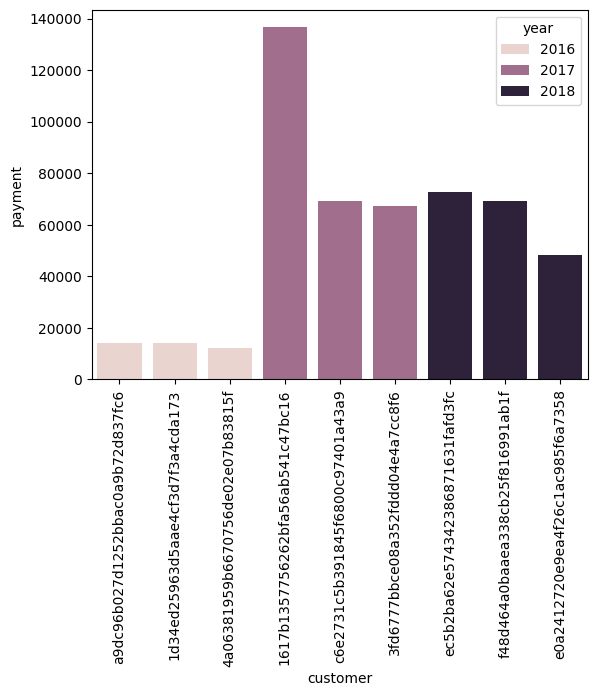

In [27]:
query = """ with a as (select orders.customer_id, year (orders.order_purchase_timestamp) as years, sum(payments.payment_value) as payment , 
dense_rank() over( partition by year (orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) as d_rank
from orders join
payments on orders.order_id= payments.order_id
group by customer_id, order_purchase_timestamp)

select a.customer_id, a.years, a.payment, a.d_rank
from a
where d_rank<=3
 	"""

cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data, columns = ("customer", "year", "payment", "rank"))
df
sns.barplot(x= "customer", y= "payment", data= df, hue= "year")
plt.xticks(rotation = 90)
plt.show()